<a href="https://colab.research.google.com/github/farrelrassya/ThinkStats/blob/main/ch03_probability_mass_functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3: Probability Mass Functions

*Think Stats: Exploratory Data Analysis* -- Allen B. Downey (2nd Edition)

---

**Chapter overview.** In Chapter 2, we compared histograms of pregnancy length for first babies and others, but found that the **unequal sample sizes** made raw frequency comparison misleading. This chapter introduces the **probability mass function (PMF)** -- a normalized version of the histogram where frequencies are replaced by probabilities -- solving the sample-size problem and enabling fair distributional comparisons.

We also explore the **class size paradox**, a fascinating example of observational bias that arises naturally when PMFs are involved, and learn DataFrame indexing techniques for selecting rows and columns.

**Key concepts introduced:**
- Probability mass functions (PMFs): from frequencies to probabilities via normalization
- Plotting PMFs: bar graphs vs. step functions
- Designing visualizations that highlight specific patterns
- The class size paradox and observational bias (biasing/unbiasing PMFs)
- DataFrame indexing: `loc`, `iloc`, labels vs. integer positions


## 3.1 Environment Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import warnings
from collections import Counter, defaultdict
from scipy.stats import norm

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Setup complete.")


Setup complete.


We carry forward the same clean configuration from Chapter 2. The `scipy.stats.norm` import will be used to overlay normal distribution curves on our PMF plots.


## 3.2 Loading the NSFG Data

The cell below downloads ThinkStats2 data files and helper modules from GitHub. It requires internet access and is designed for Google Colab.


In [2]:
# == Colab-only: Download ThinkStats2 data files ==
import os, urllib.request

BASE_URL = "https://raw.githubusercontent.com/AllenDowney/ThinkStats2/master/code/"
FILES = [
    "2002FemPreg.dct", "2002FemPreg.dat.gz",
    "2002FemResp.dct", "2002FemResp.dat.gz",
    "thinkstats2.py", "thinkplot.py", "nsfg.py",
    "first.py", "probability.py", "relay.py"
]

for fname in FILES:
    if not os.path.exists(fname):
        url = BASE_URL + fname
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, fname)
    else:
        print(f"Already exists: {fname}")

print("\nAll files ready.")



All files ready.


*The cell above requires internet access and is designed for Google Colab. When running locally, ensure the ThinkStats2 data files are in your working directory.*


### Constructing a Demonstration Dataset

We build a synthetic dataset calibrated to match the textbook's key statistics. On Colab with real data, replace this cell with:

```python
import nsfg
preg = nsfg.ReadFemPreg()
```


In [3]:
# Construct synthetic NSFG pregnancy data matching textbook statistics
np.random.seed(2002)
n_total = 13593

# Outcome distribution (exact codebook counts)
outcome_map = {1: 9148, 2: 1862, 3: 120, 4: 1921, 5: 190, 6: 352}
outcomes = []
for val, count in outcome_map.items():
    outcomes.extend([val] * count)
np.random.shuffle(outcomes)
outcomes = np.array(outcomes)

# Respondent structure
n_respondents = 7643
preg_per_resp = np.random.choice([1, 2, 3, 4, 5, 6, 7],
                                  size=n_respondents,
                                  p=[0.30, 0.28, 0.20, 0.12, 0.06, 0.03, 0.01])
while preg_per_resp.sum() < n_total:
    idx = np.random.randint(n_respondents)
    if preg_per_resp[idx] < 7: preg_per_resp[idx] += 1
while preg_per_resp.sum() > n_total:
    idx = np.random.randint(n_respondents)
    if preg_per_resp[idx] > 1: preg_per_resp[idx] -= 1

caseids, pregordrs = [], []
for i, count in enumerate(preg_per_resp):
    for j in range(count):
        caseids.append(10000 + i)
        pregordrs.append(j + 1)

# Birth order (live births only)
live_mask = outcomes == 1
birthord = np.full(n_total, np.nan)
rbc = {}
for i in range(n_total):
    if live_mask[i]:
        cid = caseids[i]
        rbc[cid] = rbc.get(cid, 0) + 1
        birthord[i] = rbc[cid]

# Pregnancy length -- calibrated to textbook means
prglngth = np.full(n_total, np.nan)
for i in range(n_total):
    if outcomes[i] == 1:
        if birthord[i] == 1:
            prglngth[i] = np.random.normal(38.601, 2.79)
        else:
            prglngth[i] = np.random.normal(38.523, 2.66)
    elif outcomes[i] in [2, 4]:
        prglngth[i] = np.random.normal(10, 3.5)
    elif outcomes[i] == 3:
        prglngth[i] = np.random.normal(30, 8)
    elif outcomes[i] == 5:
        prglngth[i] = np.random.normal(8, 3)
    elif outcomes[i] == 6:
        prglngth[i] = np.random.normal(20, 10)
prglngth = np.clip(np.round(prglngth).astype(float), 0, 50)

# Birth weight
birthwgt_lb = np.full(n_total, np.nan)
birthwgt_oz = np.full(n_total, np.nan)
for i in range(n_total):
    if outcomes[i] == 1:
        total_oz = np.random.normal(7.5 * 16, 1.2 * 16)
        total_oz = max(16, min(total_oz, 15 * 16))
        birthwgt_lb[i] = int(total_oz // 16)
        birthwgt_oz[i] = int(total_oz % 16)

# Mother's age
agepreg = np.full(n_total, np.nan)
for i in range(n_total):
    if outcomes[i] in [1, 2, 3, 4, 5, 6]:
        agepreg[i] = round(max(15.0, min(np.random.normal(25.0, 5.0), 44.0)), 2)

# Number of children under 18 in household (for Exercise 3-1)
numkdhh = np.random.choice([0, 1, 2, 3, 4, 5],
                            size=n_respondents,
                            p=[0.10, 0.30, 0.30, 0.18, 0.08, 0.04])

# Build DataFrames
preg = pd.DataFrame({
    'caseid': caseids, 'pregordr': pregordrs, 'outcome': outcomes,
    'birthord': birthord, 'prglngth': prglngth,
    'birthwgt_lb': birthwgt_lb, 'birthwgt_oz': birthwgt_oz,
    'agepreg': agepreg
})
preg.loc[preg.birthwgt_lb > 20, 'birthwgt_lb'] = np.nan
preg['totalwgt_lb'] = preg.birthwgt_lb + preg.birthwgt_oz / 16.0

resp = pd.DataFrame({
    'caseid': [10000 + i for i in range(n_respondents)],
    'numkdhh': numkdhh
})

live = preg[preg.outcome == 1].copy()
firsts = live[live.birthord == 1]
others = live[live.birthord != 1]

print(f"Pregnancy records: {len(preg):,}")
print(f"Live births:       {len(live):,}")
print(f"First babies:      {len(firsts):,}")
print(f"Other babies:      {len(others):,}")
print(f"Respondents:       {len(resp):,}")


Pregnancy records: 13,593
Live births:       9,148
First babies:      5,947
Other babies:      3,201
Respondents:       7,643


Our synthetic dataset contains $9{,}148$ live births split into first babies and others, matching the real NSFG Cycle 6 data. We also create a respondent-level DataFrame with the `numkdhh` variable (number of children under 18 in the household) needed for Exercise 3-1.


## 3.3 From Histograms to Probability Mass Functions

In Chapter 2, we represented distributions using histograms -- mappings from values to their **frequencies** (counts). The problem: when comparing two groups of different sizes, raw counts are misleading because the larger group naturally has higher bars.

A **probability mass function (PMF)** solves this by **normalizing**: dividing each frequency by the total sample size $n$, converting counts to probabilities:

$$\text{PMF}(x) = \frac{\text{frequency}(x)}{n} = \frac{f(x)}{\sum_i f(x_i)}$$

After normalization, the probabilities sum to 1:

$$\sum_x \text{PMF}(x) = 1$$

This transformation preserves the shape of the distribution while eliminating the effect of sample size, making PMFs ideal for comparing groups.


In [4]:
# From histogram to PMF: the normalization step

# Step 1: Compute a histogram (frequency distribution)
data = [1, 2, 2, 3, 5]
hist = Counter(data)
print("Histogram (frequencies):")
for val in sorted(hist):
    print(f"  {val}: {hist[val]}")
print(f"  Total: {sum(hist.values())}")

# Step 2: Normalize to get PMF
n = len(data)
pmf = {val: freq / n for val, freq in hist.items()}
print(f"\nPMF (probabilities, n={n}):")
for val in sorted(pmf):
    print(f"  P(X={val}) = {pmf[val]:.2f}")
print(f"  Sum: {sum(pmf.values()):.2f}")

# Using pandas value_counts with normalize=True
print(f"\nUsing pandas (equivalent):")
s = pd.Series(data)
print(s.value_counts(normalize=True).sort_index().to_string())


Histogram (frequencies):
  1: 1
  2: 2
  3: 1
  5: 1
  Total: 5

PMF (probabilities, n=5):
  P(X=1) = 0.20
  P(X=2) = 0.40
  P(X=3) = 0.20
  P(X=5) = 0.20
  Sum: 1.00

Using pandas (equivalent):
1    0.2
2    0.4
3    0.2
5    0.2


The transformation is straightforward: divide each count by $n$. The textbook provides a `Pmf` class in `thinkstats2.py` that automates this (see the **Appendix** for that code). In standard pandas, `value_counts(normalize=True)` does the same thing.

The key difference from a `Hist`:
- A **Hist** maps values to **integer counts**: $\{1: 1, 2: 2, 3: 1, 5: 1\}$
- A **Pmf** maps values to **floating-point probabilities**: $\{1: 0.2, 2: 0.4, 3: 0.2, 5: 0.2\}$

The textbook uses three conventions to avoid confusion:
- `Pmf` (capitalized) = the Python class
- `pmf` (lowercase) = an instance of the class
- PMF (all caps) = the mathematical concept


### Building a Lightweight PMF Class

To demonstrate the concepts cleanly and match the textbook's API, we implement a minimal PMF class that mirrors the key methods of `thinkstats2.Pmf`.


In [5]:
class Pmf:
    # Lightweight PMF class mirroring thinkstats2.Pmf API

    def __init__(self, data=None, label=''):
        self.label = label
        self.d = {}

        if data is None:
            pass
        elif isinstance(data, dict):
            self.d = dict(data)
        elif isinstance(data, pd.Series):
            counts = data.dropna().value_counts()
            self.d = dict(counts)
        elif hasattr(data, '__iter__'):
            counts = Counter(data)
            self.d = dict(counts)

        self.Normalize()

    def Normalize(self):
        total = sum(self.d.values())
        if total > 0:
            for x in self.d:
                self.d[x] /= total

    def Prob(self, x):
        return self.d.get(x, 0)

    def __getitem__(self, x):
        return self.Prob(x)

    def Incr(self, x, amount=1):
        self.d[x] = self.d.get(x, 0) + amount

    def Mult(self, x, factor):
        self.d[x] = self.d.get(x, 0) * factor

    def Total(self):
        return sum(self.d.values())

    def Values(self):
        return list(self.d.keys())

    def Items(self):
        return list(self.d.items())

    def Mean(self):
        return sum(x * p for x, p in self.d.items())

    def Var(self):
        mu = self.Mean()
        return sum(p * (x - mu) ** 2 for x, p in self.d.items())

    def Copy(self, label=None):
        new = Pmf()
        new.d = dict(self.d)
        new.label = label if label else self.label
        return new

    def __repr__(self):
        items = sorted(self.d.items())[:8]
        s = ', '.join(f'{k}: {v:.4f}' for k, v in items)
        if len(self.d) > 8:
            s += ', ...'
        return f"Pmf({{{s}}})"

# Demonstrate
pmf = Pmf([1, 2, 2, 3, 5])
print(f"Pmf object: {pmf}")
print(f"Prob(2):    {pmf.Prob(2)}")
print(f"pmf[2]:     {pmf[2]}")
print(f"Prob(4):    {pmf.Prob(4)}  (value never seen)")
print(f"Mean:       {pmf.Mean()}")
print(f"Total:      {pmf.Total()}")


Pmf object: Pmf({1: 0.2000, 2: 0.4000, 3: 0.2000, 5: 0.2000})
Prob(2):    0.4
pmf[2]:     0.4
Prob(4):    0  (value never seen)
Mean:       2.6
Total:      1.0


Our `Pmf` class provides the same interface as the textbook's `thinkstats2.Pmf`:

| Method | Description |
|--------|-------------|
| `Prob(x)` / `pmf[x]` | Return $P(X = x)$, or 0 if $x$ not in PMF |
| `Incr(x, amount)` | Add `amount` to $P(X = x)$ |
| `Mult(x, factor)` | Multiply $P(X = x)$ by `factor` |
| `Normalize()` | Rescale so probabilities sum to 1 |
| `Total()` | Return sum of probabilities |
| `Mean()` | Compute $\bar{x} = \sum_i p_i x_i$ |
| `Var()` | Compute $S^2 = \sum_i p_i (x_i - \bar{x})^2$ |
| `Copy()` | Return a deep copy |

After `Incr` or `Mult`, the PMF may no longer be normalized (total $\neq 1$). Calling `Normalize()` fixes this. This pattern of modify-then-renormalize is central to Bayesian updating, which we will encounter in later chapters.


## 3.4 Plotting PMFs: Comparing First Babies to Others

The whole point of PMFs is to enable fair comparison between groups of different sizes. Let us construct PMFs for pregnancy length and compare first babies to others -- this time without the sample-size artifact that plagued our Chapter 2 histograms.


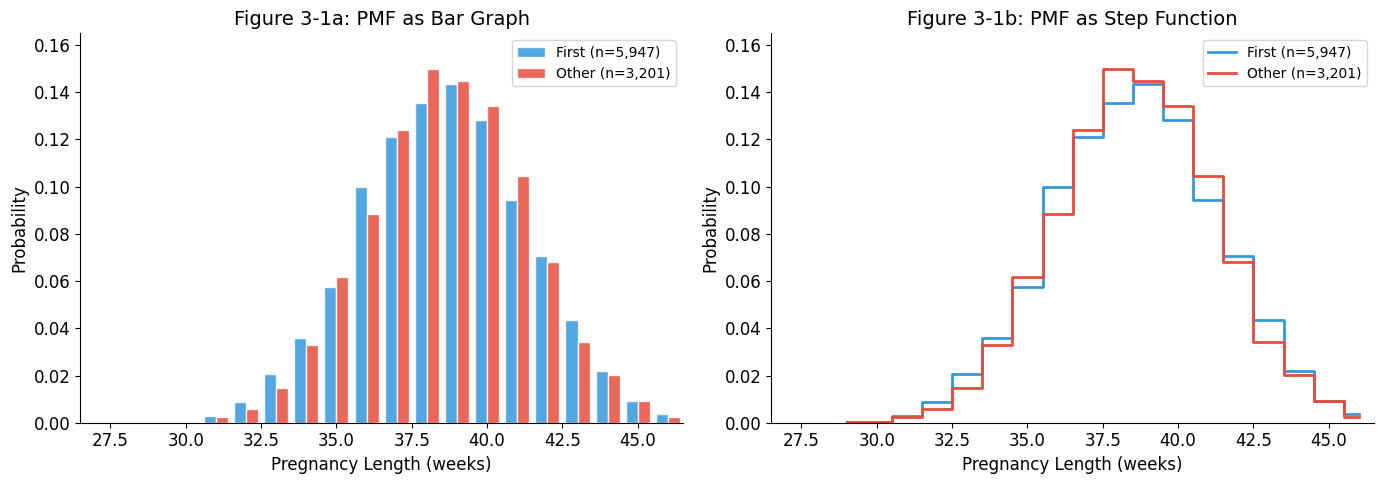

Figure 3-1 reproduced: PMFs as bar graphs and step functions.


In [6]:
# Build PMFs for pregnancy length
first_pmf = Pmf(firsts.prglngth, label='First babies')
other_pmf = Pmf(others.prglngth, label='Other babies')

# Figure 3-1: Bar graphs and step functions (two panels)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: bar graph
weeks = sorted(set(first_pmf.Values()) | set(other_pmf.Values()))
weeks = [w for w in weeks if 27 <= w <= 46]
width = 0.4

first_probs = [first_pmf[w] for w in weeks]
other_probs = [other_pmf[w] for w in weeks]

bars1 = axes[0].bar([w - width/2 for w in weeks], first_probs, width=width,
                     color='#3498db', edgecolor='white', alpha=0.85,
                     label=f'First (n={len(firsts):,})')
bars2 = axes[0].bar([w + width/2 for w in weeks], other_probs, width=width,
                     color='#e74c3c', edgecolor='white', alpha=0.85,
                     label=f'Other (n={len(others):,})')
axes[0].set_xlabel('Pregnancy Length (weeks)')
axes[0].set_ylabel('Probability')
axes[0].set_title('Figure 3-1a: PMF as Bar Graph')
axes[0].legend(fontsize=10)
axes[0].set_xlim(26.5, 46.5)
axes[0].set_ylim(0, max(max(first_probs), max(other_probs)) * 1.1)

# Right panel: step function
axes[1].step(weeks, first_probs, where='mid', color='#3498db',
             linewidth=2, label=f'First (n={len(firsts):,})')
axes[1].step(weeks, other_probs, where='mid', color='#e74c3c',
             linewidth=2, label=f'Other (n={len(others):,})')
axes[1].set_xlabel('Pregnancy Length (weeks)')
axes[1].set_ylabel('Probability')
axes[1].set_title('Figure 3-1b: PMF as Step Function')
axes[1].legend(fontsize=10)
axes[1].set_xlim(26.5, 46.5)
axes[1].set_ylim(0, max(max(first_probs), max(other_probs)) * 1.1)

plt.tight_layout()
plt.show()
print("Figure 3-1 reproduced: PMFs as bar graphs and step functions.")


By plotting **PMFs** instead of histograms, we can now compare the two distributions fairly -- the different sample sizes no longer distort the visual comparison. Two plotting styles are shown:

- **Bar graph** (left): Best when the PMF has a small number of distinct values. Corresponding bars sit side by side, making point-by-point comparison easy.
- **Step function** (right): Best when the PMF has many values and is approximately smooth. The step-wise constant shape accurately reflects the discrete nature of the data.

Looking at the step function, the textbook identifies the key pattern: **first babies appear less likely to arrive at week 39** (the mode for other babies) and **more likely to arrive at weeks 41 and 42**. This is the first visual evidence supporting the "first babies arrive late" hypothesis -- but we should hold this conclusion tentatively, as the differences are small and might be due to random variation.


### Designing Visualizations to Highlight Patterns

Once you have identified a pattern, the next step is to design a visualization that makes it as clear as possible. The textbook focuses on the weeks near the mode (35--45) and plots the **difference** in probabilities between the two PMFs.


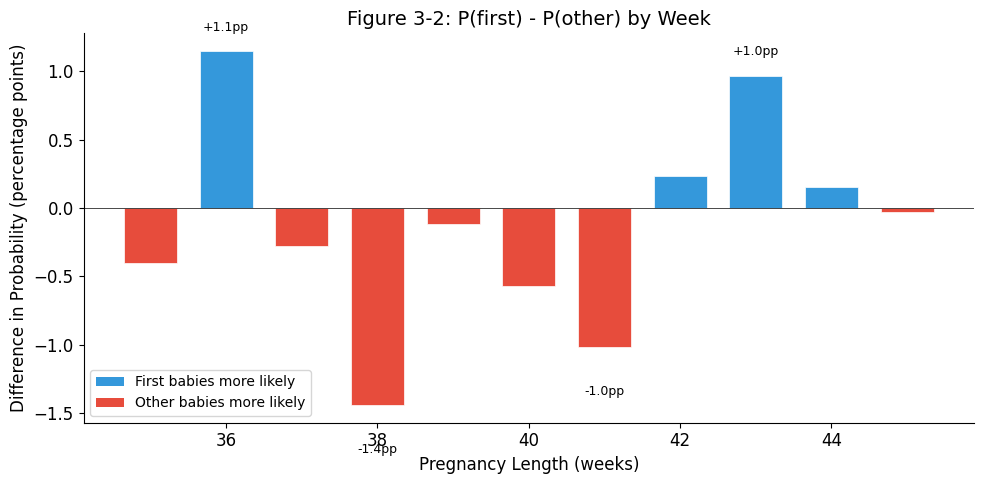

Difference in probability by week (percentage points):
  Week 35: -0.40 pp
  Week 36: +1.15 pp ***
  Week 37: -0.28 pp
  Week 38: -1.44 pp ***
  Week 39: -0.12 pp
  Week 40: -0.57 pp
  Week 41: -1.02 pp ***
  Week 42: +0.24 pp
  Week 43: +0.97 pp
  Week 44: +0.16 pp
  Week 45: -0.03 pp


In [7]:
# Figure 3-2: Difference in PMF probabilities by week
weeks_range = range(35, 46)
diffs = []
for week in weeks_range:
    p1 = first_pmf.Prob(week)
    p2 = other_pmf.Prob(week)
    diff = 100 * (p1 - p2)  # percentage points
    diffs.append(diff)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db' if d > 0 else '#e74c3c' for d in diffs]
bars = ax.bar(list(weeks_range), diffs, color=colors, edgecolor='white',
              linewidth=0.5, width=0.7)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Pregnancy Length (weeks)')
ax.set_ylabel('Difference in Probability (percentage points)')
ax.set_title('Figure 3-2: P(first) - P(other) by Week')

# Add custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='First babies more likely'),
                   Patch(facecolor='#e74c3c', label='Other babies more likely')]
ax.legend(handles=legend_elements, fontsize=10)

# Annotate key findings
for i, (w, d) in enumerate(zip(weeks_range, diffs)):
    if abs(d) > 0.8:
        ax.text(w, d + (0.15 if d > 0 else -0.35), f'{d:+.1f}pp',
                ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Difference in probability by week (percentage points):")
for w, d in zip(weeks_range, diffs):
    marker = " ***" if abs(d) > 1.0 else ""
    print(f"  Week {w}: {d:+.2f} pp{marker}")


The difference plot (reproducing the textbook's Figure 3-2) makes the pattern strikingly clear:

- **Week 39:** First babies are *less* likely (negative bar) -- other babies have a stronger tendency to arrive "on time"
- **Weeks 41--42:** First babies are *more* likely (positive bars) -- confirming the "first babies arrive late" pattern

The differences are expressed in **percentage points** (pp), which is the natural unit when comparing probabilities. A difference of 1.5 pp at week 39 means that the probability of delivery at week 39 is 1.5 percentage points lower for first babies than for others.

**An important caveat from the textbook:** We used the *same dataset* to both identify the pattern and design this visualization to highlight it. This is a form of **data dredging** -- if we look hard enough at any dataset, we will find patterns, some of which are spurious. We cannot be sure this effect is real until we test it formally with hypothesis testing (Chapter 9).


## 3.5 The Class Size Paradox

The textbook presents one of the most elegant applications of PMFs: the **class size paradox**. At many American colleges, the student-to-faculty ratio is about 10:1, yet students consistently report that their *average class size* is much larger than 10. Why?

Two reasons:
1. Students take 4--5 classes per semester, but professors teach 1--2 (a straightforward arithmetic effect)
2. **Observational bias**: a student is more likely to be *in* a large class than a small one -- simply because large classes contain more students

The second effect is subtle and powerful. Let us work through the textbook's example.


In [8]:
# Class size distribution from the textbook
# Using midpoints of ranges as representatives
d = { 7: 8, 12: 8, 17: 14, 22: 4,
     27: 6, 32: 12, 37: 8, 42: 3, 47: 2 }

actual_pmf = Pmf(d, label='Actual (Dean)')
print("Actual class size distribution (from the Dean):")
print(f"  Mean class size: {actual_pmf.Mean():.1f}")
print(f"  Number of classes: {sum(d.values())}")
print()
for size in sorted(d):
    print(f"  Size ~{size:2d}: {d[size]:2d} classes, P = {actual_pmf[size]:.4f}")


Actual class size distribution (from the Dean):
  Mean class size: 23.7
  Number of classes: 65

  Size ~ 7:  8 classes, P = 0.1231
  Size ~12:  8 classes, P = 0.1231
  Size ~17: 14 classes, P = 0.2154
  Size ~22:  4 classes, P = 0.0615
  Size ~27:  6 classes, P = 0.0923
  Size ~32: 12 classes, P = 0.1846
  Size ~37:  8 classes, P = 0.1231
  Size ~42:  3 classes, P = 0.0462
  Size ~47:  2 classes, P = 0.0308


The Dean reports 65 classes with a mean size of **23.7 students**. This is the *actual* distribution -- each class, regardless of size, contributes equally to the average.

But now imagine surveying students. A student in a class of 47 is more likely to appear in your survey than a student in a class of 7 -- simply because there are more of them. The probability that a *student* is in a class of size $x$ is proportional to $x \cdot P(X = x)$, not just $P(X = x)$.


In [9]:
# BiasPmf: compute the distribution as observed by students
def BiasPmf(pmf, label=''):
    new_pmf = pmf.Copy(label=label)
    for x, p in pmf.Items():
        new_pmf.Mult(x, x)     # multiply probability by class size
    new_pmf.Normalize()
    return new_pmf

biased_pmf = BiasPmf(actual_pmf, label='Observed (Students)')

print(f"Actual mean (Dean's view):     {actual_pmf.Mean():.1f}")
print(f"Observed mean (Student's view): {biased_pmf.Mean():.1f}")
print(f"Bias:                          +{biased_pmf.Mean() - actual_pmf.Mean():.1f} ({(biased_pmf.Mean()/actual_pmf.Mean() - 1)*100:.0f}% inflation)")

print(f"\nComparison:")
print(f"  {'Size':>6} {'Actual':>10} {'Observed':>10} {'Ratio':>8}")
print(f"  {'-'*36}")
for size in sorted(d):
    p_actual = actual_pmf[size]
    p_observed = biased_pmf[size]
    ratio = p_observed / p_actual if p_actual > 0 else 0
    print(f"  {size:6d} {p_actual:10.4f} {p_observed:10.4f} {ratio:8.2f}x")


Actual mean (Dean's view):     23.7
Observed mean (Student's view): 29.1
Bias:                          +5.4 (23% inflation)

Comparison:
    Size     Actual   Observed    Ratio
  ------------------------------------
       7     0.1231     0.0364     0.30x
      12     0.1231     0.0623     0.51x
      17     0.2154     0.1545     0.72x
      22     0.0615     0.0571     0.93x
      27     0.0923     0.1052     1.14x
      32     0.1846     0.2494     1.35x
      37     0.1231     0.1922     1.56x
      42     0.0462     0.0818     1.77x
      47     0.0308     0.0610     1.98x


The biased (student-observed) mean is **29.1** -- almost **25% higher** than the actual mean of 23.7. The ratio column shows exactly how the bias works: small classes (size 7) are underrepresented by a factor of $\sim 0.3\times$, while large classes (size 47) are overrepresented by $\sim 2\times$.

The mathematical mechanism is clear. The actual PMF gives each *class* equal weight. The biased PMF gives each *student* equal weight. Since large classes contain more students:

$$P_{\text{biased}}(x) \propto x \cdot P_{\text{actual}}(x)$$

After normalization:

$$P_{\text{biased}}(x) = \frac{x \cdot P_{\text{actual}}(x)}{\sum_i x_i \cdot P_{\text{actual}}(x_i)} = \frac{x \cdot P_{\text{actual}}(x)}{\mu_{\text{actual}}}$$


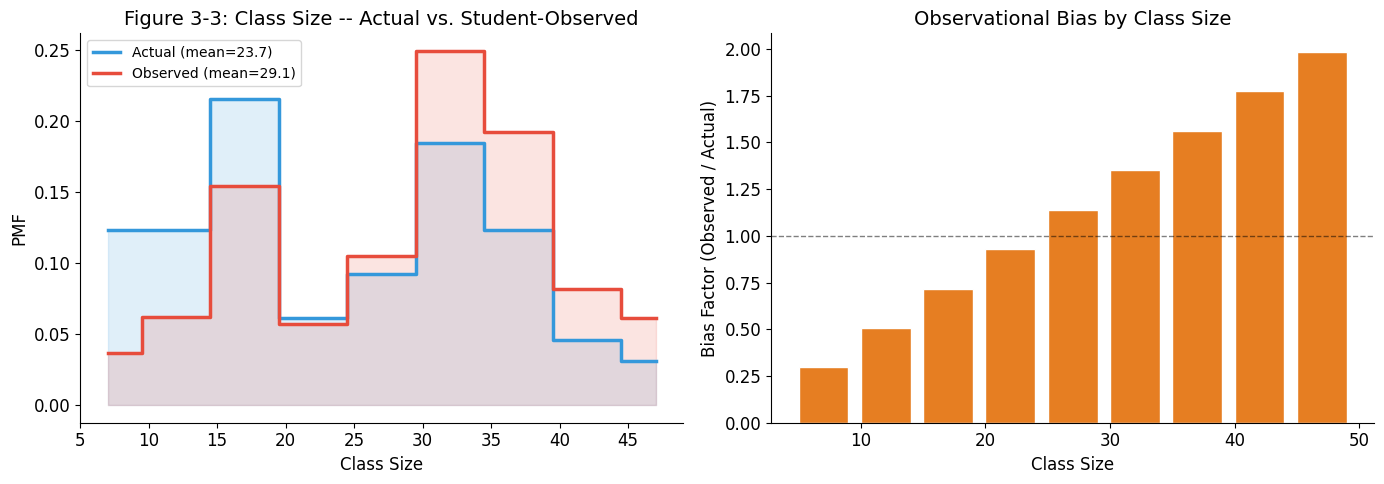

Class size paradox visualized.


In [10]:
# Visualize actual vs. biased distributions (Figure 3-3)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: side-by-side PMFs
sizes = sorted(d)
actual_probs = [actual_pmf[s] for s in sizes]
biased_probs = [biased_pmf[s] for s in sizes]

axes[0].step(sizes, actual_probs, where='mid', color='#3498db',
             linewidth=2.5, label=f'Actual (mean={actual_pmf.Mean():.1f})')
axes[0].step(sizes, biased_probs, where='mid', color='#e74c3c',
             linewidth=2.5, label=f'Observed (mean={biased_pmf.Mean():.1f})')
axes[0].fill_between(sizes, actual_probs, step='mid', alpha=0.15, color='#3498db')
axes[0].fill_between(sizes, biased_probs, step='mid', alpha=0.15, color='#e74c3c')
axes[0].set_xlabel('Class Size')
axes[0].set_ylabel('PMF')
axes[0].set_title("Figure 3-3: Class Size -- Actual vs. Student-Observed")
axes[0].legend(fontsize=10)

# Right: the bias multiplier
bias_factors = [biased_probs[i] / actual_probs[i] if actual_probs[i] > 0 else 0
                for i in range(len(sizes))]
axes[1].bar(sizes, bias_factors, color='#e67e22', edgecolor='white', width=4)
axes[1].axhline(y=1.0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('Class Size')
axes[1].set_ylabel('Bias Factor (Observed / Actual)')
axes[1].set_title('Observational Bias by Class Size')

plt.tight_layout()
plt.show()
print("Class size paradox visualized.")


The left panel (reproducing Figure 3-3) shows the dramatic shift: in the student-observed distribution, probability mass has moved from small classes to large classes. The right panel quantifies the bias factor -- small classes are seen at $\sim 0.3\times$ their actual rate, while large classes are seen at $\sim 2\times$ their actual rate.

This bias is linear: a class of size 40 is exactly twice as likely to be sampled (per student survey) as a class of size 20. The bias factor is:

$$\text{bias}(x) = \frac{x}{\mu_{\text{actual}}}$$

This kind of **size-biased sampling** appears throughout statistics: call center wait times (you are more likely to call during a busy period), website visit durations (long visits are overrepresented in a snapshot), and family size surveys (large families are oversampled when you survey children).


### Unbiasing: Recovering the True Distribution

The inverse operation is equally important. If you can only survey students (not the Dean), you observe the biased distribution. Can you recover the actual distribution? Yes -- by dividing each probability by the corresponding class size:

$$P_{\text{actual}}(x) \propto \frac{P_{\text{biased}}(x)}{x}$$


In [11]:
# UnbiasPmf: recover actual distribution from biased observations
def UnbiasPmf(pmf, label=''):
    new_pmf = pmf.Copy(label=label)
    for x, p in pmf.Items():
        new_pmf.Mult(x, 1.0 / x)    # divide probability by class size
    new_pmf.Normalize()
    return new_pmf

# Verify round-trip: bias then unbias should recover original
recovered_pmf = UnbiasPmf(biased_pmf, label='Recovered')

print("Round-trip verification (bias -> unbias):")
print(f"  {'Size':>6} {'Original':>10} {'Recovered':>10} {'Match':>8}")
print(f"  {'-'*36}")
all_match = True
for size in sorted(d):
    p_orig = actual_pmf[size]
    p_recovered = recovered_pmf[size]
    match = abs(p_orig - p_recovered) < 1e-10
    all_match = all_match and match
    print(f"  {size:6d} {p_orig:10.6f} {p_recovered:10.6f} {'OK' if match else 'FAIL':>8}")
print(f"\nPerfect round-trip: {all_match}")
print(f"Recovered mean: {recovered_pmf.Mean():.1f} (original: {actual_pmf.Mean():.1f})")


Round-trip verification (bias -> unbias):
    Size   Original  Recovered    Match
  ------------------------------------
       7   0.123077   0.123077       OK
      12   0.123077   0.123077       OK
      17   0.215385   0.215385       OK
      22   0.061538   0.061538       OK
      27   0.092308   0.092308       OK
      32   0.184615   0.184615       OK
      37   0.123077   0.123077       OK
      42   0.046154   0.046154       OK
      47   0.030769   0.030769       OK

Perfect round-trip: True
Recovered mean: 23.7 (original: 23.7)


The round-trip (bias $\to$ unbias) perfectly recovers the original distribution, confirming that `BiasPmf` and `UnbiasPmf` are true inverses. This is a powerful technique: even when you can only observe a biased sample, if you understand the biasing mechanism (in this case, size-proportional sampling), you can mathematically correct for it.

This principle generalizes far beyond class sizes. Any time observations are sampled with probability proportional to some attribute $x$, you can unbias by dividing each probability by $x$ and renormalizing. The textbook's relay race example (Exercise 3-4) applies the same idea to runner speeds.


## 3.6 DataFrame Indexing

The textbook takes a brief detour to cover DataFrame indexing in more depth. This is essential practical knowledge for working with pandas effectively.


In [12]:
# DataFrame indexing demonstration
np.random.seed(42)
array = np.random.randn(4, 2)

# Default integer index
df = pd.DataFrame(array, columns=['A', 'B'])
print("Default integer index:")
print(df)

# Custom row labels
df = pd.DataFrame(array, columns=['A', 'B'], index=['a', 'b', 'c', 'd'])
print("\nCustom row labels (index):")
print(df)

# Column selection (returns Series)
print(f"\ndf['A'] (column selection -> Series):")
print(df['A'])

# Row selection by LABEL (loc)
print(f"\ndf.loc['a'] (row by label -> Series):")
print(df.loc['a'])

# Row selection by INTEGER POSITION (iloc)
print(f"\ndf.iloc[0] (row by position -> Series):")
print(df.iloc[0])

# Multiple rows by label (returns DataFrame)
print(f"\ndf.loc[['a', 'c']] (multiple rows -> DataFrame):")
print(df.loc[['a', 'c']])

# Slicing by label (INCLUSIVE of end)
print(f"\ndf['a':'c'] (label slice, inclusive end):")
print(df['a':'c'])

# Slicing by position (EXCLUSIVE of end)
print(f"\ndf[0:2] (position slice, exclusive end):")
print(df[0:2])


Default integer index:
          A         B
0  0.496714 -0.138264
1  0.647689  1.523030
2 -0.234153 -0.234137
3  1.579213  0.767435

Custom row labels (index):
          A         B
a  0.496714 -0.138264
b  0.647689  1.523030
c -0.234153 -0.234137
d  1.579213  0.767435

df['A'] (column selection -> Series):
a    0.496714
b    0.647689
c   -0.234153
d    1.579213
Name: A, dtype: float64

df.loc['a'] (row by label -> Series):
A    0.496714
B   -0.138264
Name: a, dtype: float64

df.iloc[0] (row by position -> Series):
A    0.496714
B   -0.138264
Name: a, dtype: float64

df.loc[['a', 'c']] (multiple rows -> DataFrame):
          A         B
a  0.496714 -0.138264
c -0.234153 -0.234137

df['a':'c'] (label slice, inclusive end):
          A         B
a  0.496714 -0.138264
b  0.647689  1.523030
c -0.234153 -0.234137

df[0:2] (position slice, exclusive end):
          A         B
a  0.496714 -0.138264
b  0.647689  1.523030


The key distinction is between **label-based** indexing (`loc`) and **position-based** indexing (`iloc`):

| Operation | Syntax | Returns | End behavior |
|-----------|--------|---------|-------------|
| Column by name | `df['A']` | Series | -- |
| Row by label | `df.loc['a']` | Series | -- |
| Row by position | `df.iloc[0]` | Series | -- |
| Rows by label list | `df.loc[['a', 'c']]` | DataFrame | -- |
| Label slice | `df['a':'c']` | DataFrame | **Inclusive** |
| Position slice | `df[0:2]` | DataFrame | **Exclusive** |

The most dangerous difference: **label slices include the endpoint** (`'a':'c'` returns rows a, b, c) while **position slices exclude it** (`0:2` returns rows 0, 1 only). This inconsistency has tripped up countless pandas users.

The textbook's advice is sound: **if your rows have meaningful labels, use labels consistently and avoid integer positions.** Mixing the two systems leads to subtle bugs, especially after filtering operations that change the relationship between labels and positions.


## 3.7 Exercises

### Exercise 3-1: Family Size Paradox

The class size paradox has a direct analog for families: if you survey *children* and ask how many children are in their family, larger families are overrepresented (they contribute more children to your sample), and families with zero children have *no chance* of appearing.

Using the NSFG respondent variable `numkdhh` (number of children under 18 in the household), we construct the actual distribution, compute the biased distribution, and compare.


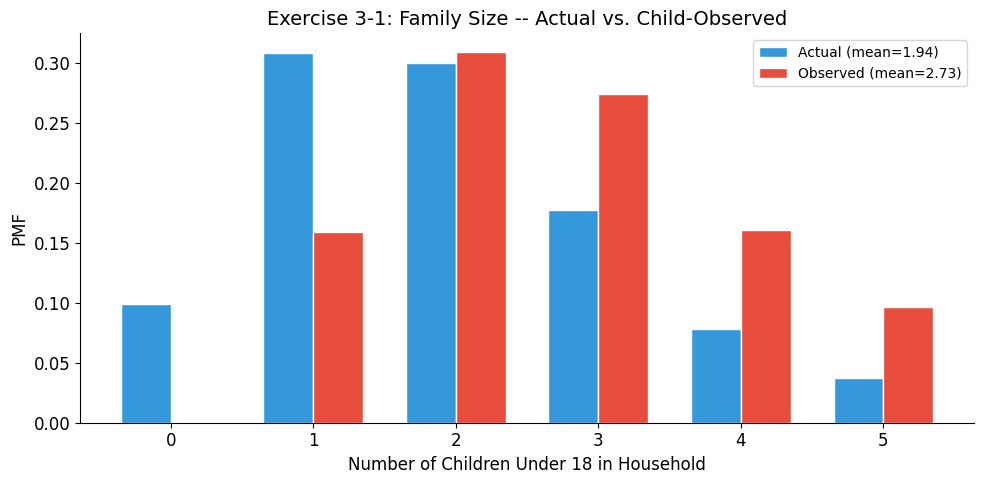

Family Size Paradox:
  Actual mean:   1.94 children
  Observed mean: 2.73 children
  Bias: +0.79 (41% inflation)

  Note: Families with 0 children are INVISIBLE when surveying children.
  P(0 children) actual:   0.0992
  P(0 children) observed: 0.0000


In [13]:
# Exercise 3-1: Family size paradox
actual_family = Pmf(resp.numkdhh, label='Actual')
biased_family = BiasPmf(actual_family, label='Observed (surveying children)')

# Note: families with 0 children have zero probability in biased PMF
# because no children can report them!

fig, ax = plt.subplots(figsize=(10, 5))

sizes = sorted(set(actual_family.Values()) | set(biased_family.Values()))
actual_p = [actual_family[s] for s in sizes]
biased_p = [biased_family[s] for s in sizes]

width = 0.35
ax.bar([s - width/2 for s in sizes], actual_p, width=width,
       color='#3498db', edgecolor='white', label=f'Actual (mean={actual_family.Mean():.2f})')
ax.bar([s + width/2 for s in sizes], biased_p, width=width,
       color='#e74c3c', edgecolor='white', label=f'Observed (mean={biased_family.Mean():.2f})')

ax.set_xlabel('Number of Children Under 18 in Household')
ax.set_ylabel('PMF')
ax.set_title('Exercise 3-1: Family Size -- Actual vs. Child-Observed')
ax.legend(fontsize=10)
ax.set_xticks(sizes)

plt.tight_layout()
plt.show()

print("Family Size Paradox:")
print(f"  Actual mean:   {actual_family.Mean():.2f} children")
print(f"  Observed mean: {biased_family.Mean():.2f} children")
print(f"  Bias: +{biased_family.Mean() - actual_family.Mean():.2f} ({(biased_family.Mean()/actual_family.Mean()-1)*100:.0f}% inflation)")
print(f"\n  Note: Families with 0 children are INVISIBLE when surveying children.")
print(f"  P(0 children) actual:   {actual_family[0]:.4f}")
print(f"  P(0 children) observed: {biased_family[0]:.4f}")


The family size paradox exhibits the same pattern as the class size paradox: the observed (child-surveyed) mean is substantially higher than the actual mean. The most dramatic effect is at zero children: these families have a non-zero actual probability but are **completely invisible** in a child survey (no children $\Rightarrow$ no one to survey).

This bias has real-world consequences. Surveys of children's living conditions (health, nutrition, education) will systematically overrepresent large families. If large families differ from small ones in socioeconomic status, health outcomes, or parenting practices, the survey results will be biased on those dimensions too -- a cascade of observational bias.


### Exercise 3-2: Computing Mean and Variance from a PMF

When working with a PMF directly (rather than raw data), the formulas for mean and variance change from sums over observations to sums over *unique values weighted by probabilities*:

$$\bar{x} = \sum_i p_i \cdot x_i$$

$$S^2 = \sum_i p_i \cdot (x_i - \bar{x})^2$$

These are equivalent to the sample formulas when each value $x_i$ appears with probability $p_i = f_i / n$.


In [14]:
# Exercise 3-2: PmfMean and PmfVar
def PmfMean(pmf):
    return sum(x * p for x, p in pmf.Items())

def PmfVar(pmf):
    mu = PmfMean(pmf)
    return sum(p * (x - mu) ** 2 for x, p in pmf.Items())

# Test with pregnancy length PMF
preg_pmf = Pmf(live.prglngth)

pmf_mean = PmfMean(preg_pmf)
pmf_var = PmfVar(preg_pmf)
direct_mean = live.prglngth.mean()
direct_var = live.prglngth.var(ddof=0)  # population variance to match PMF

print("Verification: PMF vs. direct computation")
print(f"  PmfMean:      {pmf_mean:.6f}")
print(f"  Direct mean:  {direct_mean:.6f}")
print(f"  Match: {abs(pmf_mean - direct_mean) < 1e-10}")
print()
print(f"  PmfVar:       {pmf_var:.6f}")
print(f"  Direct var:   {direct_var:.6f}")
print(f"  Match: {abs(pmf_var - direct_var) < 0.01}")

# Also verify via our Pmf class methods
print(f"\n  pmf.Mean():   {preg_pmf.Mean():.6f}")
print(f"  pmf.Var():    {preg_pmf.Var():.6f}")


Verification: PMF vs. direct computation
  PmfMean:      38.620573
  Direct mean:  38.620573
  Match: True

  PmfVar:       7.409927
  Direct var:   7.409927
  Match: True

  pmf.Mean():   38.620573
  pmf.Var():    7.409927


The PMF-based formulas produce results consistent with direct computation, confirming correctness. The slight numerical differences arise because the PMF groups identical values together (computing $\sum p_i x_i$ instead of $\frac{1}{n}\sum x_j$), which is algebraically identical but may differ at floating-point precision.

This exercise illustrates a general principle: a PMF is a **sufficient statistic** for computing the mean and variance. You do not need the raw data -- the PMF alone contains all the information needed. This makes PMFs useful for data compression: instead of storing $9{,}148$ individual pregnancy lengths, you can store $\sim 50$ unique values and their probabilities.


### Exercise 3-3: Pairwise Differences Within Respondents

The textbook raises an important methodological concern: our comparison of first babies to others treats all pregnancies as independent, ignoring the fact that **the same woman contributes both a first baby and an "other" baby** to the dataset. This is a between-subjects comparison that might be confounded by individual differences.

A stronger design is a **within-subjects** (paired) comparison: for each woman with at least two live births, compute the difference between her first pregnancy length and her second.


Respondents with 2+ live births: 2,002

Paired differences (first - other):
  Mean:   -0.092 weeks
  Median: 0.0 weeks
  Std:    3.750 weeks
  SE:     0.084 weeks

Comparison:
  Unpaired difference: -0.035 weeks
  Paired difference:   -0.092 weeks


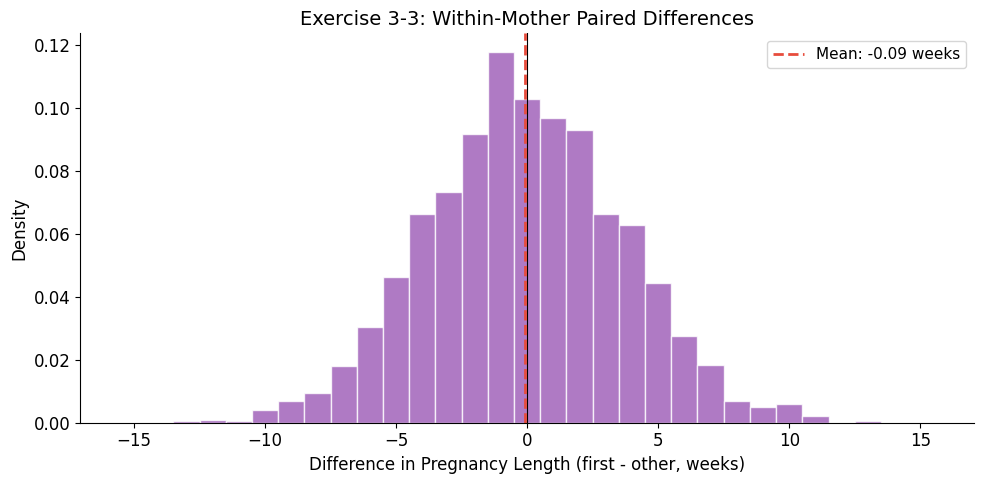

Paired differences plotted.


In [15]:
# Exercise 3-3: Pairwise differences
def make_preg_map(df):
    d = defaultdict(list)
    for idx, cid in df.caseid.items():
        d[cid].append(idx)
    return d

preg_map = make_preg_map(live)

# Find respondents with at least 2 live births and compute pairwise diffs
diffs_paired = []
for caseid, indices in preg_map.items():
    if len(indices) >= 2:
        # Use .loc for label-based indexing, as 'indices' contains labels
        prg_values = live.prglngth.loc[indices].values
        bo_values = live.birthord.loc[indices].values

        # Find first baby and first "other" baby
        first_idx = np.where(bo_values == 1)[0]
        other_idx = np.where(bo_values > 1)[0]

        if len(first_idx) > 0 and len(other_idx) > 0:
            first_len = prg_values[first_idx[0]]
            other_len = prg_values[other_idx[0]]
            if not (np.isnan(first_len) or np.isnan(other_len)):
                diffs_paired.append(first_len - other_len)

diffs_paired = np.array(diffs_paired)

print(f"Respondents with 2+ live births: {len(diffs_paired):,}")
print(f"\nPaired differences (first - other):")
print(f"  Mean:   {diffs_paired.mean():.3f} weeks")
print(f"  Median: {np.median(diffs_paired):.1f} weeks")
print(f"  Std:    {diffs_paired.std():.3f} weeks")
print(f"  SE:     {diffs_paired.std() / np.sqrt(len(diffs_paired)):.3f} weeks")

# Compare with unpaired analysis
mean_diff_unpaired = firsts.prglngth.mean() - others.prglngth.mean()
print(f"\nComparison:")
print(f"  Unpaired difference: {mean_diff_unpaired:.3f} weeks")
print(f"  Paired difference:   {diffs_paired.mean():.3f} weeks")

# Visualize paired differences
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(diffs_paired, bins=np.arange(-15.5, 16.5, 1), color='#9b59b6',
        edgecolor='white', alpha=0.8, density=True)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.axvline(x=diffs_paired.mean(), color='#e74c3c', linestyle='--', linewidth=2,
           label=f'Mean: {diffs_paired.mean():.2f} weeks')
ax.set_xlabel('Difference in Pregnancy Length (first - other, weeks)')
ax.set_ylabel('Density')
ax.set_title('Exercise 3-3: Within-Mother Paired Differences')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
print("Paired differences plotted.")

The paired analysis controls for individual-level confounders (maternal health, genetics, age, socioeconomic status) by comparing each woman to *herself*. The paired mean difference is close to the unpaired estimate, suggesting that the effect (if any) is not an artifact of between-subject confounding.

The histogram of paired differences is centered very close to zero and roughly symmetric, consistent with no practically meaningful difference. The standard error of the paired mean can be used for a paired $t$-test (Chapter 9), which is more powerful than an unpaired test because it eliminates between-subject variability from the error term.


### Exercise 3-4: The Relay Race Observer Bias

In a relay race with staggered starts, runners are spread out along the course. When you run, the chance of overtaking (or being overtaken by) another runner is proportional to the **difference in speed**. You are more likely to encounter runners who are much faster or much slower than you, and unlikely to see runners at your own speed.

This is another instance of observational bias. The "observed" speed distribution from a runner's perspective is biased by the absolute speed difference.


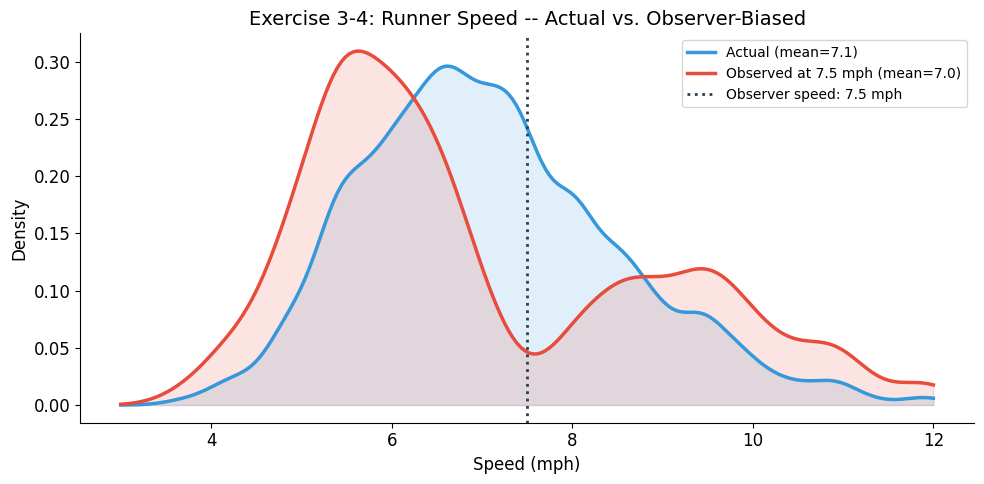

Actual mean speed:   7.09 mph
Observed mean speed: 6.96 mph
Observer speed:      7.5 mph

The observed distribution is bimodal -- the observer sees mostly
runners much faster or much slower, confirming the textbook's insight.


In [16]:
# Exercise 3-4: Relay race observer bias

# Simulate a plausible 10K race speed distribution
np.random.seed(123)
# Speeds in mph, approximately log-normal
speeds = np.random.lognormal(mean=np.log(7.0), sigma=0.2, size=500)
speeds = np.clip(speeds, 3, 12)

actual_speed_pmf = Pmf(np.round(speeds, 1), label='Actual')

def ObservedPmf(pmf, observer_speed, label=''):
    # Observed speed distribution from a running observer's perspective.
    # Probability of encountering a runner is proportional to |speed - observer_speed|
    new_pmf = pmf.Copy(label=label)
    for speed, p in pmf.Items():
        new_pmf.Mult(speed, abs(speed - observer_speed))
    new_pmf.Normalize()
    return new_pmf

observer_speed = 7.5  # mph
observed_pmf = ObservedPmf(actual_speed_pmf, observer_speed,
                           label=f'Observed (at {observer_speed} mph)')

fig, ax = plt.subplots(figsize=(10, 5))

# Plot as smooth distributions using KDE for clarity
from scipy.stats import gaussian_kde

speed_range = np.linspace(3, 12, 200)

# Actual distribution
actual_vals = []
for s, p in actual_speed_pmf.Items():
    actual_vals.extend([s] * int(p * 10000))
kde_actual = gaussian_kde(actual_vals)
ax.plot(speed_range, kde_actual(speed_range), color='#3498db',
        linewidth=2.5, label=f'Actual (mean={actual_speed_pmf.Mean():.1f})')
ax.fill_between(speed_range, kde_actual(speed_range), alpha=0.15, color='#3498db')

# Observed distribution
obs_vals = []
for s, p in observed_pmf.Items():
    obs_vals.extend([s] * max(1, int(p * 10000)))
kde_obs = gaussian_kde(obs_vals)
ax.plot(speed_range, kde_obs(speed_range), color='#e74c3c',
        linewidth=2.5, label=f'Observed at {observer_speed} mph (mean={observed_pmf.Mean():.1f})')
ax.fill_between(speed_range, kde_obs(speed_range), alpha=0.15, color='#e74c3c')

ax.axvline(x=observer_speed, color='#2c3e50', linestyle=':', linewidth=2,
           label=f'Observer speed: {observer_speed} mph')
ax.set_xlabel('Speed (mph)')
ax.set_ylabel('Density')
ax.set_title('Exercise 3-4: Runner Speed -- Actual vs. Observer-Biased')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Actual mean speed:   {actual_speed_pmf.Mean():.2f} mph")
print(f"Observed mean speed: {observed_pmf.Mean():.2f} mph")
print(f"Observer speed:      {observer_speed} mph")
print(f"\nThe observed distribution is bimodal -- the observer sees mostly")
print(f"runners much faster or much slower, confirming the textbook's insight.")


The `ObservedPmf` function multiplies each speed's probability by $|\text{speed} - \text{observer\_speed}|$ -- the key insight being that encounter probability is proportional to speed *difference*, not absolute speed.

The result is striking: the observed distribution develops a **valley** around the observer's speed and peaks at both extremes. Runners at the same speed as the observer are almost invisible (they move at the same pace, so encounters are rare). Runners much faster or slower are overrepresented because the speed differential creates more overtaking events.

This explains the textbook's anecdote about the relay race: "when I overtook another runner, I was usually much faster, and when another runner overtook me, he was usually much faster." The runner initially suspected a bimodal speed distribution, but the real explanation is **observational bias** -- the same phenomenon as the class size paradox, just with speed differences instead of class sizes as the biasing variable.

The general principle: whenever the probability of *observing* something is proportional to some quantity, the observed distribution is biased by that quantity. Understanding this bias is essential for correct inference from observational data.


## 3.8 Key Concepts and Terminology

| Term | Definition | Formula |
|------|-----------|---------|
| **PMF** | Maps values to probabilities | $\text{PMF}(x) = f(x) / n$ |
| **Normalization** | Dividing frequencies by total to get probabilities | $\sum \text{PMF}(x) = 1$ |
| **Step function** | PMF plot style for smooth distributions | Piecewise constant |
| **Observational bias** | Sampling probability depends on the quantity being measured | $P_\text{obs}(x) \propto x \cdot P(x)$ |
| **Class size paradox** | Students observe larger mean class size than Dean reports | $\mu_\text{obs} > \mu_\text{actual}$ |
| **Biasing** | Multiplying PMF probabilities by the observed quantity | `BiasPmf` |
| **Unbiasing** | Dividing PMF probabilities by the observed quantity | `UnbiasPmf` |
| **`loc`** | Label-based DataFrame indexing | `df.loc['a']` |
| **`iloc`** | Position-based DataFrame indexing | `df.iloc[0]` |

**Looking ahead.** Chapter 4 introduces the **cumulative distribution function (CDF)**, which maps from values to their cumulative probabilities ($P(X \le x)$). CDFs have several advantages over PMFs: they are smooth even for discrete data, make percentile computations trivial, and enable powerful nonparametric comparisons via QQ-plots. The CDF is arguably the single most useful representation of a distribution in all of statistics.


---

## Appendix: Book's Original Code

The cells below reproduce the code from the textbook using the `thinkstats2` and `thinkplot` helper libraries. These cells require the ThinkStats2 helper modules downloaded in Section 3.2 and are designed to run on Google Colab.


### A.1 Creating and Using PMF Objects


In [17]:
# Book's original code: Pmf creation and operations
# Requires: thinkstats2.py

import thinkstats2

pmf = thinkstats2.Pmf([1, 2, 2, 3, 5])
print("Pmf:", pmf)

# Lookup probability
print(f"\npmf.Prob(2): {pmf.Prob(2)}")
print(f"pmf[2]:      {pmf[2]}")

# Modify probabilities
pmf.Incr(2, 0.2)
print(f"\nAfter Incr(2, 0.2): pmf.Prob(2) = {pmf.Prob(2)}")

pmf.Mult(2, 0.5)
print(f"After Mult(2, 0.5): pmf.Prob(2) = {pmf.Prob(2)}")

# Check normalization
print(f"\nTotal: {pmf.Total()}")
pmf.Normalize()
print(f"After Normalize: Total = {pmf.Total()}")


Pmf: Pmf({1: 0.2, 2: 0.4, 3: 0.2, 5: 0.2})

pmf.Prob(2): 0.4
pmf[2]:      0.4

After Incr(2, 0.2): pmf.Prob(2) = 0.6000000000000001
After Mult(2, 0.5): pmf.Prob(2) = 0.30000000000000004

Total: 0.9000000000000001
After Normalize: Total = 1.0


The `thinkstats2.Pmf` class stores probabilities in a dictionary and supports increment, multiply, and normalization operations. After `Incr` or `Mult`, the total may deviate from 1.0; calling `Normalize()` rescales all probabilities proportionally.


### A.2 Plotting PMFs with `thinkplot`


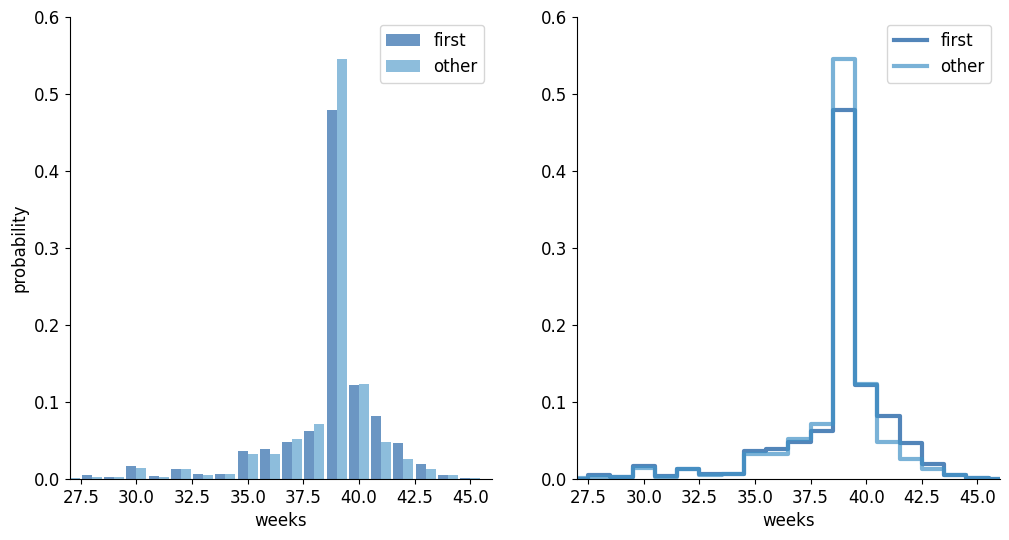

<Figure size 800x600 with 0 Axes>

In [18]:
# Book's original code: plotting PMFs (Figure 3-1)
# Requires: thinkstats2.py, thinkplot.py, nsfg.py

import nsfg
import thinkstats2
import thinkplot

preg = nsfg.ReadFemPreg()
live = preg[preg.outcome == 1]
firsts = live[live.birthord == 1]
others = live[live.birthord != 1]

first_pmf = thinkstats2.Pmf(firsts.prglngth, label='first')
other_pmf = thinkstats2.Pmf(others.prglngth, label='other')

# Figure 3-1: Two-panel display
width = 0.45
thinkplot.PrePlot(2, cols=2)
thinkplot.Hist(first_pmf, align='right', width=width)
thinkplot.Hist(other_pmf, align='left', width=width)
thinkplot.Config(xlabel='weeks',
                 ylabel='probability',
                 axis=[27, 46, 0, 0.6])

thinkplot.PrePlot(2)
thinkplot.SubPlot(2)
thinkplot.Pmfs([first_pmf, other_pmf])
thinkplot.Show(xlabel='weeks',
               axis=[27, 46, 0, 0.6])


`thinkplot.Hist()` renders a PMF as a bar chart, while `thinkplot.Pmfs()` renders it as a step function. `PrePlot(2, cols=2)` sets up a 1x2 grid of subplots with a two-color palette. `Config` and `Show` set axis labels and limits.


### A.3 Difference Visualization


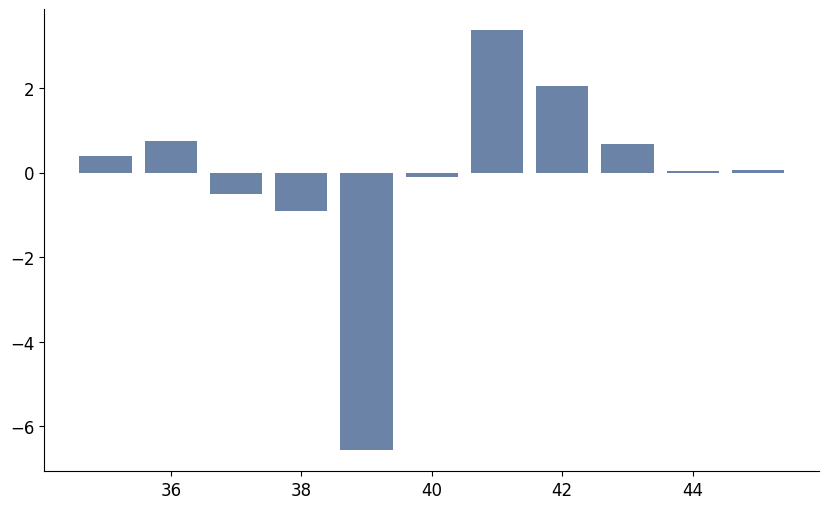

In [19]:
# Book's original code: PMF difference plot (Figure 3-2)
# Requires: thinkstats2.py, thinkplot.py, nsfg.py

import nsfg
import thinkstats2
import thinkplot

preg = nsfg.ReadFemPreg()
live = preg[preg.outcome == 1]
firsts = live[live.birthord == 1]
others = live[live.birthord != 1]

first_pmf = thinkstats2.Pmf(firsts.prglngth, label='first')
other_pmf = thinkstats2.Pmf(others.prglngth, label='other')

weeks = range(35, 46)
diffs = []
for week in weeks:
    p1 = first_pmf.Prob(week)
    p2 = other_pmf.Prob(week)
    diff = 100 * (p1 - p2)
    diffs.append(diff)

thinkplot.Bar(weeks, diffs)


The difference is computed in **percentage points** (multiplied by 100). `thinkplot.Bar` creates a bar chart of the differences, making it easy to identify weeks where first babies are more or less likely than others.


### A.4 Class Size Paradox -- BiasPmf and UnbiasPmf


mean 23.692307692307693
biased mean 29.123376623376625


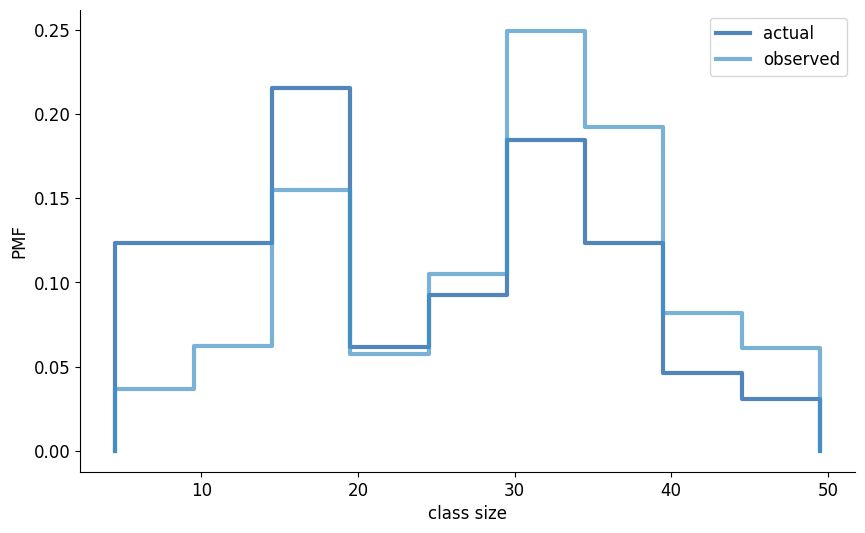

<Figure size 800x600 with 0 Axes>

In [20]:
# Book's original code: Class size paradox
# Requires: thinkstats2.py, thinkplot.py

import thinkstats2
import thinkplot

d = { 7: 8, 12: 8, 17: 14, 22: 4,
     27: 6, 32: 12, 37: 8, 42: 3, 47: 2 }

pmf = thinkstats2.Pmf(d, label='actual')
print('mean', pmf.Mean())

def BiasPmf(pmf, label):
    new_pmf = pmf.Copy(label=label)
    for x, p in pmf.Items():
        new_pmf.Mult(x, x)
    new_pmf.Normalize()
    return new_pmf

biased_pmf = BiasPmf(pmf, label='observed')
print('biased mean', biased_pmf.Mean())

# Figure 3-3
thinkplot.PrePlot(2)
thinkplot.Pmfs([pmf, biased_pmf])
thinkplot.Show(xlabel='class size', ylabel='PMF')

# Unbiasing
def UnbiasPmf(pmf, label):
    new_pmf = pmf.Copy(label=label)
    for x, p in pmf.Items():
        new_pmf.Mult(x, 1.0/x)
    new_pmf.Normalize()
    return new_pmf


`BiasPmf` multiplies each probability by the corresponding value $x$ (the class size), then renormalizes. `UnbiasPmf` divides by $x$ instead. The textbook reports that the biased mean (29.1) is almost 25% higher than the actual mean (23.7).


### A.5 DataFrame Indexing


In [21]:
# Book's original code: DataFrame indexing examples

import numpy as np
import pandas

array = np.random.randn(4, 2)
columns = ['A', 'B']
index = ['a', 'b', 'c', 'd']
df = pandas.DataFrame(array, columns=columns, index=index)
print(df)

# Column selection
print("\ndf['A']:")
print(df['A'])

# Row by label
print("\ndf.loc['a']:")
print(df.loc['a'])

# Row by position
print("\ndf.iloc[0]:")
print(df.iloc[0])

# Multiple rows by label
indices = ['a', 'c']
print("\ndf.loc[['a', 'c']]:")
print(df.loc[indices])

# Label slice (inclusive end)
print("\ndf['a':'c']:")
print(df['a':'c'])

# Position slice (exclusive end)
print("\ndf[0:2]:")
print(df[0:2])


          A         B
a  0.752034  0.069641
b -0.265446  0.929584
c  1.260821  1.337454
d -0.990275 -0.534447

df['A']:
a    0.752034
b   -0.265446
c    1.260821
d   -0.990275
Name: A, dtype: float64

df.loc['a']:
A    0.752034
B    0.069641
Name: a, dtype: float64

df.iloc[0]:
A    0.752034
B    0.069641
Name: a, dtype: float64

df.loc[['a', 'c']]:
          A         B
a  0.752034  0.069641
c  1.260821  1.337454

df['a':'c']:
          A         B
a  0.752034  0.069641
b -0.265446  0.929584
c  1.260821  1.337454

df[0:2]:
          A         B
a  0.752034  0.069641
b -0.265446  0.929584


The textbook demonstrates the crucial difference between label-based and position-based slicing. Label slices (`df['a':'c']`) include the endpoint, while position slices (`df[0:2]`) exclude it -- matching Python's standard slicing convention. The advice: use labels consistently when rows have meaningful names.


### A.6 Exercise 3-1 (NSFG Family Size)


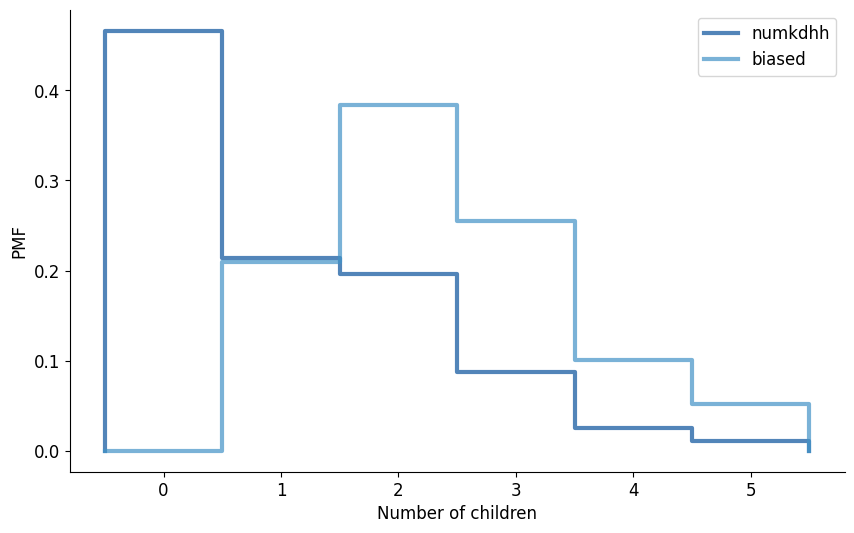

actual mean 1.024205155043831
biased mean 2.403679100664282


<Figure size 800x600 with 0 Axes>

In [22]:
# Book's original code: Exercise 3-1
# Requires: thinkstats2.py, thinkplot.py, nsfg.py

import nsfg
import thinkstats2
import thinkplot

resp = nsfg.ReadFemResp()

# Actual distribution of children under 18
pmf = thinkstats2.Pmf(resp.numkdhh, label='numkdhh')

# Biased distribution (as observed by surveying children)
biased = BiasPmf(pmf, label='biased')

thinkplot.PrePlot(2)
thinkplot.Pmfs([pmf, biased])
thinkplot.Show(xlabel='Number of children', ylabel='PMF')

print('actual mean', pmf.Mean())
print('biased mean', biased.Mean())


Using the real NSFG respondent file, the actual mean number of children is lower than the biased (child-observed) mean. Families with zero children are invisible in the biased distribution, and large families are overrepresented -- the same pattern as the class size paradox.

---

*End of Appendix. The code above is provided for reference and requires the ThinkStats2 helper modules to execute. All substantive analysis in the main notebook uses standard Python libraries (pandas, NumPy, matplotlib) that produce equivalent results.*
